In [20]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import missingno as msno

from sklearn.model_selection import train_test_split

In [2]:
FILE_PATH = Path.cwd().parent / "datasets" / "animal_data_dirty1.csv"

In [3]:
df = pd.read_csv(FILE_PATH,sep=';') # NOTE : Seperator is ; 

In [4]:
df.head()

,Animal type,Country,Weight kg,Body Length cm,Gender,Animal code,Latitude,Longitude,Animal name,Observation date,Data compiled by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
2,European bison,Poland,930.0,335.0,male,NaN,52.828845,23.820144,Szefu,01.03.2024,Anne Anthony
3,European bison,Poland,909.0,311.0,not determined,NaN,52.830509,23.826849,NaN,01.03.2024,Anne Anthony
4,European bison™,Poland,581.0,277.0,female,NaN,52.834109,23.807093,NaN,01.03.2024,Anne Anthony


In [114]:
def examine_dataframe(df):
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    columns_df = pd.DataFrame({
                'column' : df.columns,
                'dtype' : [x for x in df.dtypes],
                '#non_null_values' : df.notna().sum().tolist() ,
                '#null_values' : df.isna().sum().tolist() ,
                '%null_values' : [f'{x:.2f}' for x in ((df.isna().sum()/df.shape[0])*100).to_list()]
        })
    return (columns_df)
    


In [115]:
examine_dataframe(df)

Dataframe shape : (1011, 11)
----------------------------------------------------------------------------------------------------
Memory Usage : 0.35 MB
----------------------------------------------------------------------------------------------------
Column Dtypes: 
object     6
float64    5
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


,column,dtype,#non_null_values,#null_values,%null_values
0,Animal type,object,991,20,1.98
1,Country,object,999,12,1.19
2,Weight kg,float64,984,27,2.67
3,Body Length cm,float64,984,27,2.67
4,Gender,object,992,19,1.88
5,Animal code,float64,0,1011,100.00
6,Latitude,float64,913,98,9.69
7,Longitude,float64,913,98,9.69
8,Animal name,object,52,959,94.86
9,Observation date,object,1011,0,0.00


## The main aim of this notebook is to practice cleaning on the dataset .

In [19]:
# There seems to have a lot of null values in here , we have to move cautiously when dealing with missing values to check whether they are MAR , MCAR or MCNAR.

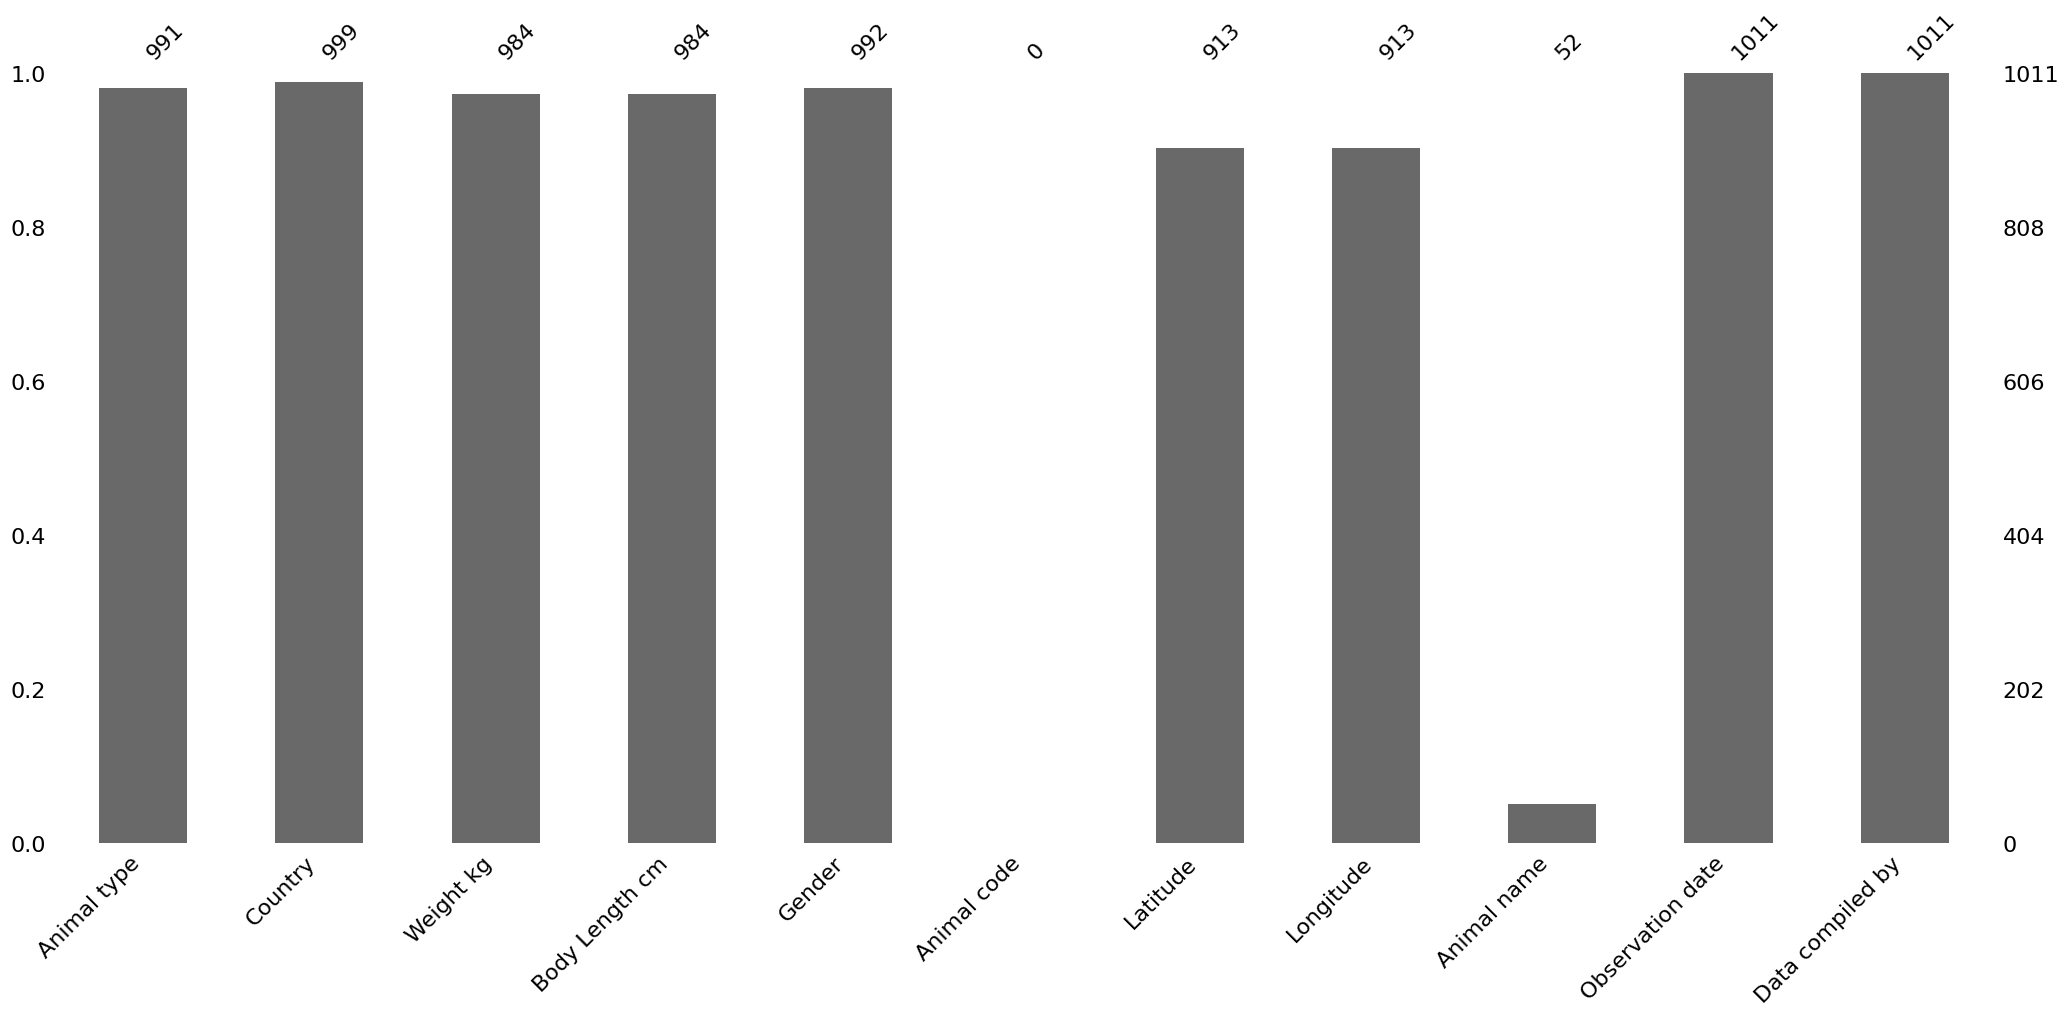

In [25]:
# Let's check whether this missingness is randome or not
msno.bar(df)
plt.show()
# Plot the bar graph which displays us the number of NoN NULL values

### Evaluating NULL values : 
    Animal code : Completely Missing and cannot be recovered will be forced to drop. 
    Animal name : Again Almost Completely Missing with some 52 values left ( may be dropped ).
>   Rest of the columns shall be handled by various transformations and techniques.